### __Imports__

In [13]:
import cv2
import os
import matplotlib.pyplot as plt

__Pipeline Structure Idea:__
Load Pictures from Folder → Convert into Grayscale → Resize → Save

### __Process One Image__

In [8]:
def process_image(path, size=(128, 128)):
    img = cv2.imread(path)

    if img is None:
        return None
    
    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Resize Pictures to same size
    gray = cv2.resize(gray, size)

    return gray

### __Dataset Pipeline__

In [9]:
def process_dataset(input_dir, output_dir, size=(128, 128)):
    os.makedirs(output_dir, exist_ok=True)

    for file in os.listdir(input_dir):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            
            input_path = os.path.join(input_dir, file)
            gray = process_image(input_path, size)

            if gray is None:
                continue

            output_path = os.path.join(output_dir, file)
            cv2.imwrite(output_path, gray)

    print("Done.")

In [10]:
process_dataset(
    input_dir="data/images/drawings",
    output_dir="data/grayscale_drawings",
    size=(128, 128)
)

Done.


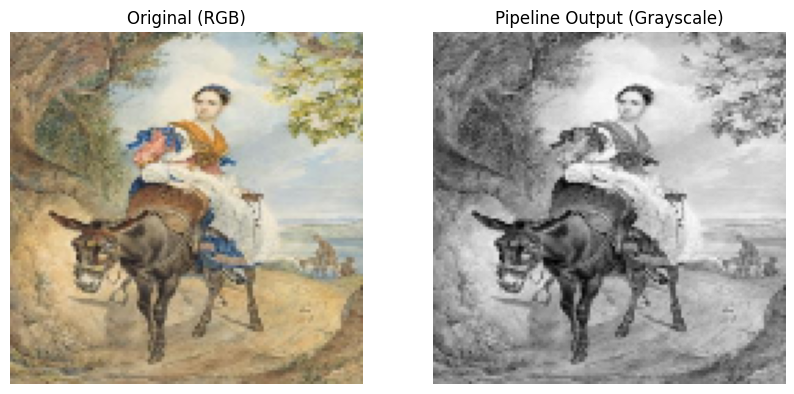

----------------------------
Pipeline Output is Grayscale
----------------------------


In [19]:
# Example Image from Dataset
path = "data/images/drawings/2206_mainfoto_05.jpg"

# Load Original
image = cv2.imread(path)

# Process
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_image = cv2.resize(gray_image, (128, 128))

# Resize
image_resized = cv2.resize(image, (128, 128))

# Plot
plt.figure(figsize=(10, 5))

# Original (RGB)
plt.subplot(1, 2, 1)
plt.title("Original (RGB)")
plt.imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Grayscale
plt.subplot(1, 2, 2)
plt.title("Pipeline Output (Grayscale)")
plt.imshow(gray_image, cmap='gray')
plt.axis('off')

plt.show()

# Check
if gray_image.ndim == 2:
    print("----------------------------")
    print("Pipeline Output is Grayscale")
    print("----------------------------")